# Customer Churn Analysis
by: [Al Fath Terry](https://www.linkedin.com/in/al-fath-terry/)

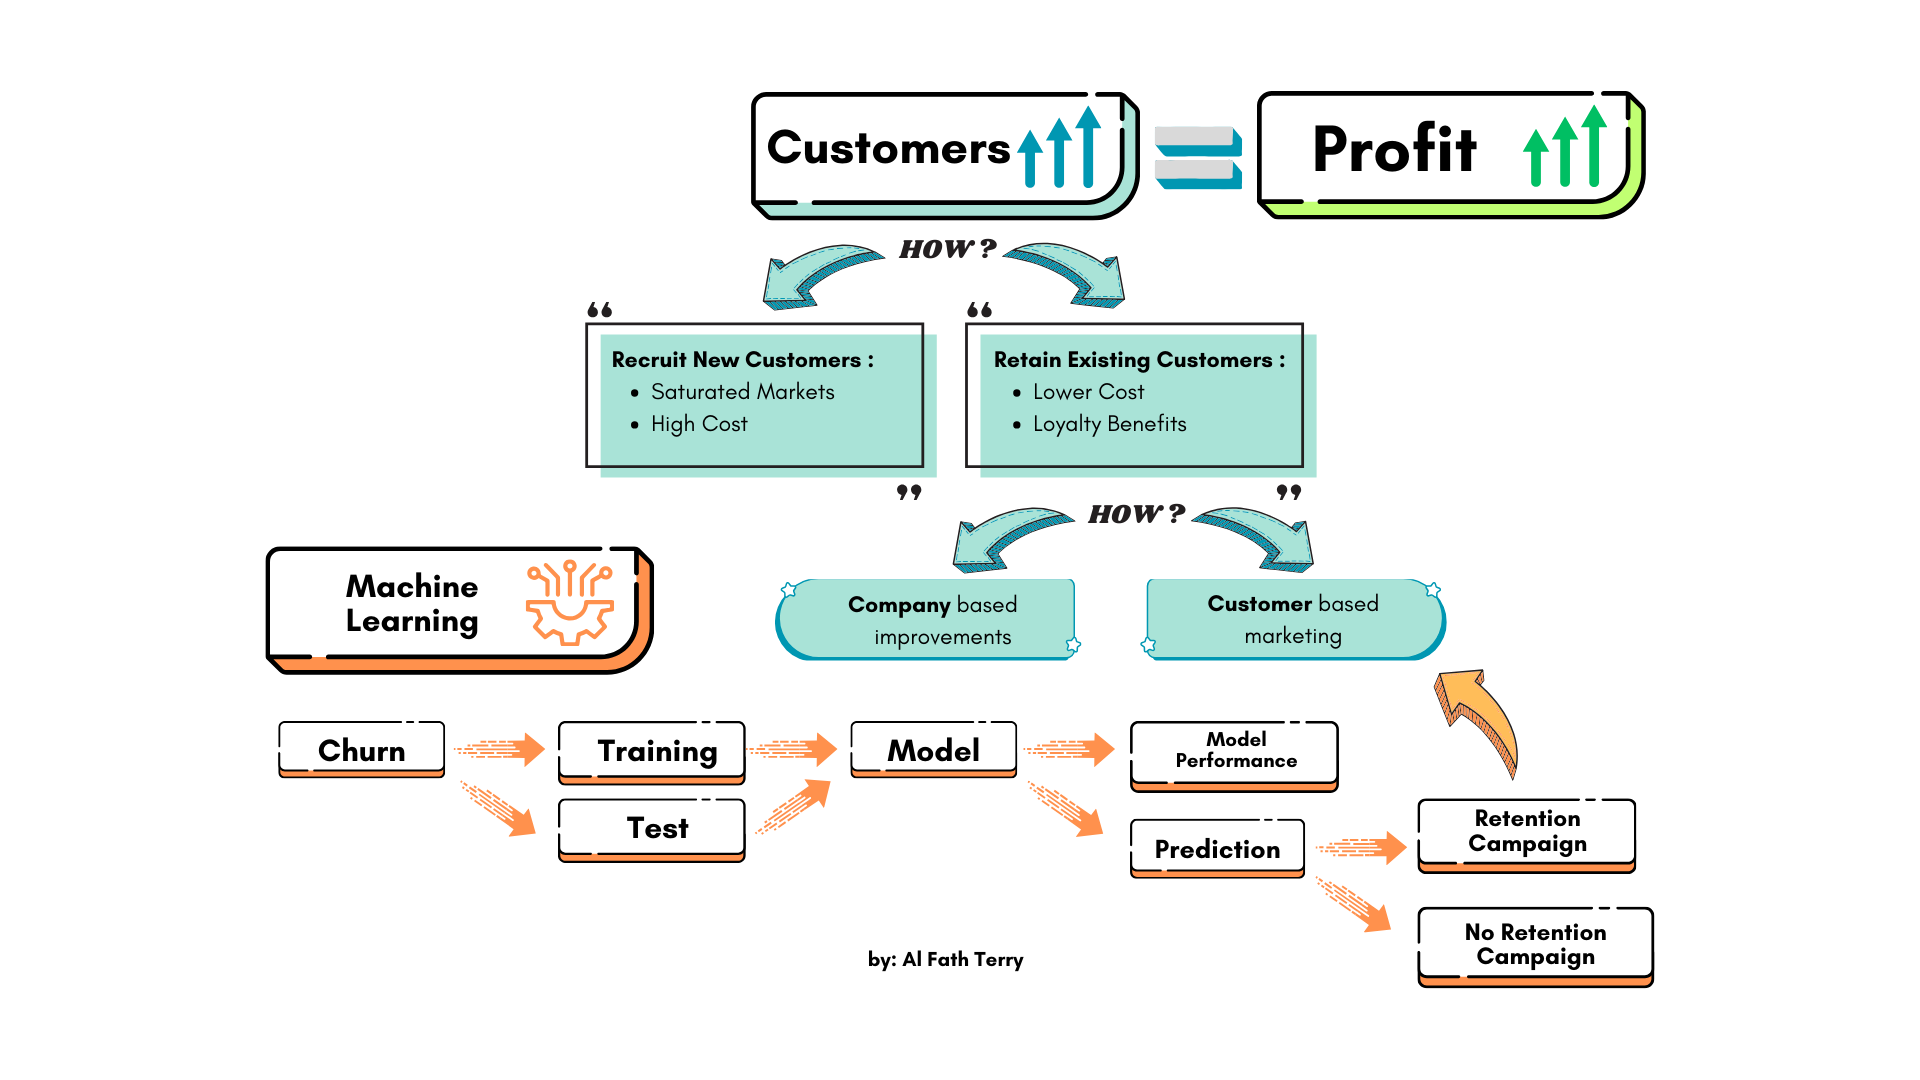

Source data:
- https://www.kaggle.com/datasets/blastchar/telco-customer-churn
- https://www.kaggle.com/datasets/ylchang/telco-customer-churn-1113

# Library

In [ ]:

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
#pd.reset_option('display.max_rows')
import matplotlib.pyplot as plt
import matplotlib as mpl 
import seaborn as sns
sns.set_theme(style='white') 
%matplotlib inline
import re
import math 
import plotly.express as px 
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import six  
from numpy import random as rand 
import plotly.io as pio
pio.renderers.default = "notebook_connected"
import plotly.figure_factory as ff
from sklearn.preprocessing import PowerTransformer,FunctionTransformer, KBinsDiscretizer,OrdinalEncoder, OneHotEncoder, LabelEncoder,StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mutual_info_score, f1_score,recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay, classification_report,mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error , roc_auc_score,auc, roc_curve,balanced_accuracy_score
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression,SelectKBest, f_classif, f_regression,chi2, SelectPercentile,RFE, VarianceThreshold
from sklearn.model_selection import cross_val_score, cross_validate,StratifiedKFold,GridSearchCV,train_test_split
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.utils.class_weight import compute_class_weight
import shap 
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
import xgboost as xgb
from catboost import CatBoostClassifier
from kmodes.kprototypes import KPrototypes
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.svm import SVC
from scipy.stats import shapiro, normaltest
from itertools import combinations
from scipy.stats import chi2_contingency,wilcoxon, mannwhitneyu, skew
import scipy.stats as ss
from IPython.display import Image 
import statsmodels.api as sm 
import warnings
warnings.filterwarnings("ignore")

# Load Data

In [ ]:

df_telco = pd.read_excel('/kaggle/input/telco-customer-churn-1113/Telco_customer_churn.xlsx').drop(columns=['Count','Country','State', 'Zip Code','Lat Long','Latitude','Longitude','Payment Method','Churn Label'])
df_demo = pd.read_excel('/kaggle/input/telco-customer-churn-1113/Telco_customer_churn_demographics.xlsx').drop(columns=['Gender','Senior Citizen','Dependents','Under 30','Count']).rename(columns={'Customer ID':'CustomerID'})
df_services = pd.read_excel('/kaggle/input/telco-customer-churn-1113/Telco_customer_churn_services.xlsx').drop(columns=['Count','Quarter','Tenure in Months','Phone Service','Multiple Lines','Internet Type','Internet Service','Online Security','Online Backup','Device Protection Plan','Streaming TV','Streaming Movies','Contract','Paperless Billing','Monthly Charge','Total Charges']).rename(columns={'Customer ID':'CustomerID'})
df_churn = pd.read_excel('/kaggle/input/telco-customer-churn-1113/Telco_customer_churn_status.xlsx').drop(columns=['Count','Quarter','Churn Label','Churn Value','Churn Reason','Churn Score','CLTV']).rename(columns={'Customer ID':'CustomerID'})
df = pd.merge(left=df_telco,right=df_demo, on='CustomerID').merge(right=df_services, on='CustomerID').merge(right=df_churn,on='CustomerID').rename(columns={'Churn Value':'Churn'}).drop(columns=['CustomerID','City','Tech Support'])
demo_graph_var = ['Gender','Age','Senior Citizen', 'Married', 'Dependents','Number of Dependents']
services_var = ['Referred a Friend','Number of Referrals','Tenure Months','Offer','Phone Service','Avg Monthly Long Distance Charges','Multiple Lines','Internet Service','Avg Monthly GB Download','Online Security','Online Backup','Device Protection','Premium Tech Support','Streaming TV','Streaming Movies','Streaming Music','Unlimited Data','Contract','Paperless Billing','Payment Method','Monthly Charges','Total Charges','Total Refunds','Total Extra Data Charges','Total Long Distance Charges','Total Revenue']
df = df[demo_graph_var+services_var+['Churn Category']+['Churn']]

# Data Understanding

### Services
- CustomerID: A unique ID that identifies each customer.

- Count: A value used in reporting/dashboarding to sum up the number of customers in a filtered set.

- Quarter: The fiscal quarter that the data has been derived from (e.g. Q3).

- Referred a Friend: Indicates if the customer has ever referred a friend or family member to this company: Yes, No

- Number of Referrals: Indicates the number of referrals to date that the customer has made.

- Tenure in Months: Indicates the total amount of months that the customer has been with the company by the end of the quarter specified above.

- Offer: Identifies the last marketing offer that the customer accepted, if applicable. Values include None, Offer A, Offer B, Offer C, Offer D, and Offer E.

- Phone Service: Indicates if the customer subscribes to home phone service with the company: Yes, No

- Avg Monthly Long Distance Charges: Indicates the customer’s average long distance charges, calculated to the end of the quarter specified above.

- Multiple Lines: Indicates if the customer subscribes to multiple telephone lines with the company: Yes, No

- Internet Service: Indicates if the customer subscribes to Internet service with the company: No, DSL, Fiber Optic, Cable.

- Avg Monthly GB Download: Indicates the customer’s average download volume in gigabytes, calculated to the end of the quarter specified above.

- Online Security: Indicates if the customer subscribes to an additional online security service provided by the company: Yes, No

- Online Backup: Indicates if the customer subscribes to an additional online backup service provided by the company: Yes, No

- Device Protection Plan: Indicates if the customer subscribes to an additional device protection plan for their Internet equipment provided by the company: Yes, No

- Premium Tech Support: Indicates if the customer subscribes to an additional technical support plan from the company with reduced wait times: Yes, No

- Streaming TV: Indicates if the customer uses their Internet service to stream television programing from a third party provider: Yes, No. The company does not charge an additional fee for this service.

- Streaming Movies: Indicates if the customer uses their Internet service to stream movies from a third party provider: Yes, No. The company does not charge an additional fee for this service.

- Streaming Music: Indicates if the customer uses their Internet service to stream music from a third party provider: Yes, No. The company does not charge an additional fee for this service.

- Unlimited Data: Indicates if the customer has paid an additional monthly fee to have unlimited data downloads/uploads: Yes, No

- Contract: Indicates the customer’s current contract type: Month-to-Month, One Year, Two Year.

- Paperless Billing: Indicates if the customer has chosen paperless billing: Yes, No

- Payment Method: Indicates how the customer pays their bill: Bank Withdrawal, Credit Card, Mailed Check

- Monthly Charge: Indicates the customer’s current total monthly charge for all their services from the company.

- Total Charges: Indicates the customer’s total charges, calculated to the end of the quarter specified above.

- Total Refunds: Indicates the customer’s total refunds, calculated to the end of the quarter specified above.

- Total Extra Data Charges: Indicates the customer’s total charges for extra data downloads above those specified in their plan, by the end of the quarter specified above.

- Total Long Distance Charges: Indicates the customer’s total charges for long distance above those specified in their plan, by the end of the quarter specified above.

### Demographics

- Gender: The customer’s gender: Male, Female

- Age: The customer’s current age, in years, at the time the fiscal quarter ended.

- Senior Citizen: Indicates if the customer is 65 or older: Yes, No

- Married: Indicates if the customer is married: Yes, No

- Dependents: Indicates if the customer lives with any dependents: Yes, No. Dependents could be children, parents, grandparents, etc.

- Number of Dependents: Indicates the number of dependents that live with the customer.

In [ ]:
print('Rows :',df.shape[0])
print('Columns :',df.shape[1]) 

Datanya memiliki 7043  baris, dan 32 kolom 

In [ ]:
df.info() 

Terdapat ketidaksesuaian tipe data, 'TotalCharges' seharusnya numeric. dan 'SeniorCitizen' dapat diubah menjadi boolean atau categoric.

In [ ]:
miss_val = df[pd.to_numeric(df['Total Charges'], errors='coerce').isnull() == True]
miss_val.shape 

Berdasarkan temuan diatas bahwa kolom 'TotalCharges' seharusnya bertipe data numeric, bukan sebagai object. oleh karena itu kita harus mengidentifikasi di index mana saja yang valuenya bukan berupa numeric, dan hasilnya terdapat 11 baris data yang mengalami missing values dikolom 'TotalCharges', jika kita amati kolom 'Tenure'nya pun juga 0, hal ini tidak masuk akal, sehingga data ini harus dihapus.

In [ ]:
# drop index yang valuenya tidak jelas
df = df.drop(index=miss_val.index).reset_index(drop=True)
# ubah tipe data kolom 'TotalCharges' menjadi float
df['Total Charges'] = df['Total Charges'].astype(float)

In [ ]:
df.isnull().sum() 

Dikolom 'Churn Category' terdapat 5163 missing value yang merepresentasikan customer yang tidak churn, untuk mengatasinya cukup ubah missing values tersebut dengan value 'no reason', kolom 'Offer' dengan "None'

In [ ]:
df['Churn Category'] = df['Churn Category'].replace({np.NaN:'no reason'}) 
df['Offer'] = df['Offer'].replace({np.NaN:'None'})

In [ ]:
numeric_var =['Age','Number of Dependents','Number of Referrals','Tenure Months','Avg Monthly Long Distance Charges','Avg Monthly GB Download','Monthly Charges','Total Charges','Total Refunds','Total Extra Data Charges','Total Long Distance Charges','Total Revenue'] 
categoric_var = [i for i in df.columns if i not in numeric_var + ['Churn']]

In [ ]:
# analisis untuk melihat cardinality data  kategorik
for i in categoric_var:
    print('Variable :',i)
    print('Unique Values :',df[i].unique())
    print('Number of Unique Values :',df[i].nunique())
    print('\n') 

High cardinality adalah kondisi dimana data kategorik memiliki banyak unique value, seperti nama kota, pekerjaan, dll. Kondisi seperti ini mempengaruhi tindakan kita dalam mengencoding data, jika ditemukan feature yang cardinalitynya tinggi, kita tidak bisa menggunakan One-hot karena featurenya akan terlalu banyak yang nerujung pada cost komputasi yang besar dan bisa terjebak dalam curse of dimentionality. Di dataset ini, data kategoriknya tidak memiliki cardinality yang tinggi.

#### *Function*

In [ ]:
# beberapa function akan saya letakkan disini agar tidak mengganggu

# function untuk menghitung asosiasi data kategorik
def get_corr_mat(df, f=chi2_contingency):
        columns = df.columns
        dm = pd.DataFrame(index=columns, columns=columns)
        for var1, var2 in combinations(columns, 2):
            cont_table = pd.crosstab(df[var1], df[var2], margins=False)
            chi2_stat = cramers_v(cont_table.values)
            dm.loc[var2, var1] = chi2_stat
            dm.loc[var1, var2] = chi2_stat
        dm.fillna(1, inplace=True)
        return dm

def cramers_v(confusion_matrix):
        """ calculate Cramers V statistic for categorial-categorial association.
            uses correction from Bergsma and Wicher,
            Journal of the Korean Statistical Society 42 (2013): 323-328
        """
        chi2 = ss.chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum()
        phi2 = chi2 / n
        r, k = confusion_matrix.shape
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        rcorr = r - ((r-1)**2)/(n-1)
        kcorr = k - ((k-1)**2)/(n-1)
        return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# function visualisasi data kategorik
cmp = 'Spectral'
def cat_viz(list_of_var):
    dem_viz = list_of_var
    bucket1 = [] 
    bucket2 = []
    bucket3 = []
    bucket4 = []
    for i in dem_viz:
        bucket1 = bucket1 +[i]*len(df[i].unique())
        for y in df[i].unique():
            bucket2.append(y)
            bucket3.append(df[(df['Churn']==1)&(df[i]==y)][i].count())
            bucket4.append(df[(df['Churn']==0)&(df[i]==y)][i].count())
    bucket5 = []
    for i ,j in zip(bucket4,bucket3):
        bucket5.append([round((i/(i+j))*100,2),round((j/(i+j))*100,2)])
    fig = go.Figure()
    # Not Churn
    fig.add_trace(go.Bar(x = [bucket1,bucket2],y = bucket4,marker_color=main_color[0],name = "Not Churn",text=[  f"{j}<br>%{i[0]}" for i,j in zip(bucket5,bucket4)]))
    # Churn
    fig.add_trace(go.Bar(x = [bucket1,bucket2],y = bucket3,marker_color=main_color[1],name = "Churn",text=[  f"{j} <br> %{i[1]}" for i,j in zip(bucket5,bucket3)]))
    fig.update_layout(title_text="Demographics Categorical Data vs Churn",title_x=0.5,title_y= 0.97, template='plotly_white') 
    # fig.show()

    cat_corr= get_corr_mat(df[list_of_var + ['Churn']])
    plt.figure(figsize=(5,5))
    sns.heatmap(cat_corr,cbar=True, annot=True, fmt='.2f', square=True, annot_kws={'size': 12}, cmap=cmp)
    # plt.show();
    return fig

# function untuk membuat report alasan churn berupa dataframe
def churn_reason_report(var,unique_val):
    filter_ = (df[var] == unique_val) & (df['Churn']==1)
    count = df[filter_]['Churn Category'].value_counts().to_frame()
    percentage = df[filter_]['Churn Category'].value_counts(normalize=True).to_frame().round(2)
    frame = pd.concat([count,percentage],axis=1).reset_index().set_axis(["Churn Reason",'Count','%'],axis=1)
    # frame.columns = pd.MultiIndex.from_arrays([[f"({var} == {unique_val})",''] , ['Count','%']])
    return frame

# function untuk visualisasi data numerik
def num_viz(var):
        skew_ = round(skew(df[var], bias=False),3)
        fig = px.histogram(
                    df, x=var,
                    marginal="box", 
                    hover_data=df.columns, 
                    template='simple_white',
                    color='Churn',
                    color_discrete_map = {0:main_color[0],1:main_color[1]} 
                ).update_layout(autosize=True,
                    height=360, 
                    width=900,
                    margin=dict(l=0,r=20,b=0,t=30,pad=10),
                    title_text='<b>{title} | skewness : {skew}'.format(title=var, skew=skew_), 
                    title_x=0.5, 
                    title_y= 0.97, 
                    template='plotly_white'
                    )
        return fig 

# Exploratory Data Analysis

Secara garis besar, tahapan EDA yang akan kita bagi menjadi dua, yang pertama untuk mencari insight bisnis, yang kedua EDA untuk Modeling.

## 1. Business Insights

In [ ]:
main_color = ['#26577C','#E55604']
df_t = df['Churn'].value_counts().reset_index().set_axis(['Churn','Count'],axis=1)
df_t['Churn'] = df_t['Churn'].replace({0:'Not Churn',1:'Churn'})
z = [main_color[0],main_color[1]]
fig = go.Figure(data=[go.Pie(labels=df_t['Churn'], values=df_t['Count'], hole=.3)]
            ).update_layout(height=550,title={'text': 'Customer Churn','y':0.96,'x':0.5,'xanchor': 'center','yanchor': 'top'},font=dict( size=15), template='plotly_white'
                            ).update_traces(marker=dict(colors=z))
fig.show()

Di dunia Bisnis dikenal dua strategi populer: akuisisi dan retensi. Strategi akuisisi pelanggan adalah strategi yang bertujuan memperoleh pelanggan baru. Sedangkan, strategi retensi pelanggan adalah strategi yang bertujuan mempertahankan pelanggan lama. Keduanya memiliki peran yang sama penting, tanpa salah satunya, bisnis tidak akan berjalan dengan baik.

Untuk dapat masuk dalam persaingan pasar dan meraih profit, bisnis harus memiliki pelanggan. Bisnis harus memiliki setidaknya beberapa pelanggan ketika diluncurkan. Strategi akuisisi pelanggan membantu memperbanyak jumlah pelanggan dan memperbesar basis pelanggan yang mulai terbentuk.


Di dalam kasus akuisisi, mungkin saja biaya akuisisi tidak benar-benar menghasilkan profit. Barulah beberapa bulan atau bahkan tahun setelahnya, dengan retensi yang kuat, hubungan dengan pelanggan mulai menghasilkan profit yang signifikan. 

Mengapa kita harus melakukan retensi pelanggan?

strategi akuisisi dinilai jauh lebih mahal daripada strategi retensi. Hal ini tidak hanya sekedar spekulasi. Dalam sebuah artikelnya, Forbes, menunjukkan bagaimana akuisisi dapat 5 kali lebih mahal daripada retensi, membuat pelanggan baru menjadi loyal juga 16 kali lebih mahal, dan 5% saja peningkatkan pada upaya retensi dapat menaikkan profit hingga 95%.  Mengapa hal ini dapat terjadi? Ini karena pelanggan belum pernah memiliki pengalaman apapun dan belum terciptanya kepercayaan dengan bisnis kita. Bisnis membutuhkan waktu dan uang untuk membuat customer tertarik dan yakin untuk membeli. Jadi, diperlukan strategi untuk menghentikan customer churn dan meretensi pelanggan yang sudah dimiliki, karena merekalah sumber utama revenue bisnis.

Karena hal tersebut, kita akan coba untuk membuat model Machine Learning yang berguna untuk mendeteksi customer yang berpotensi Churn dimasa depan, beserta analisis terhadap fenomena churn yang terjadi di perusahaan ini. 

summary :
- Problem = Customer churn.
- Goals = Menurunkan jumlah customer yang Churn.
- Objective = Membuat model Machine Learning dan juga analisis Data.
- Business Metrics =  Revenue dan Churn Rate


Pada dasarnya, data yang terdapat didata ini dapat dikelompokkan menjadi 3 kategori, yaitu data demografis, data layanan perusahaan, dan economic value. Karena banyaknya jumlah data yang ada, kita akan fokus pada hubungan tiap kategori dengan churn. 

In [ ]:
demog = ['Gender','Age','Married','Number of Dependents','Dependents','Number of Referrals','Referred a Friend']
serv = ['Phone Service','Multiple Lines','Internet Service','Online Security','Online Backup','Device Protection','Premium Tech Support','Streaming TV','Streaming Movies','Streaming Music','Unlimited Data']
serv2 = ['Contract','Paperless Billing','Payment Method','Offer']
value = ['Tenure Months','Total Charges','Monthly Charges','Total Extra Data Charges','Total Long Distance Charges','Total Refunds','Total Revenue'] 

#### *New Feature*

Setelah memahami data, kita akan membuat 3 feature baru, yaitu: Services Usage, Monetary Value, dan Customer Score.
- Services Usage adalah jumlah jasa yang customer gunakan.
- Monetary value adalah perhitungan jumlah Charges yang masuk ke perusahaan, dibagi 1000 agar unit skalanya sama seperti Number of Referral dan Services Usage.
- Cust Score adalah pemberian score terhadap customer berdasarkan jumlah Serfices usage, Number of Referrals dan Monetary Value.


fitur-fitur ini akan berguna ketika kita ingin melakukan segmentasi pelanggan nantinya.

In [ ]:
map_serv = {'Yes':1,'No':0,'No phone service':0,'DSL':1,'Fiber optic':1,'No internet service':0} 
df['Services_Usage'] = pd.DataFrame([df[i].map(map_serv) for i in serv ]).T.sum(axis=1) 
df['Cust_Score'] = df['Services_Usage'] + df['Number of Referrals'] + (df['Total Revenue'] /1000).round(2)

numeric_var = numeric_var + ['Services_Usage','Cust_Score'] 

### A. Demographics

In [ ]:
cat_viz(['Gender','Married','Dependents','Referred a Friend']).show() 

Proporsi Gender antara Male dan Female terhadap Churn terlihat identik, Gender tidak memiliki asosiasi terhadap customer yang akan churn atau tidak, hal ini juga didukung oleh heatmap Cramer's v dengan koefisien 0 (Cramer's v digunakan untuk menghitung kekuatan asosiasi antar data categoric). 

Sedangkan customer yang tidak memiliki dependents dan belum menikah lebih berpeluang untuk churn, hasil ini sedikit counter intuitif karena jika customer tidak memiliki pasangan dan kerabat, maka space uang customer seharusnya lebih luas dan tidak perlu churn, bukan begitu? namun alasan tersebut tidak berlaku jika customer berhasil menemukan kompetitor yang lebih bagus. agar lebih pasti, mari kita cari tahu penyebabnya

In [ ]:
display( 
    churn_reason_report('Married','No'),
    churn_reason_report('Dependents','No')
    )

Ternyata penyebab utama customer yang tidak menikah dan tidak memiliki dependents untuk churn adalah Competitor, Attitude, dan Dissatisfaction.

In [ ]:
for i in ['Age','Number of Dependents','Number of Referrals']:
    num_viz(i).show()

Satu dari beberapa strategi marketing yang efektif sepanjang masa adalah strategi Word of Mouth (WOM). Sebuah penelitian pada pelanggan global menunjukkan 92% pelanggan sangat mempercayai rekomendasi yang diberikan oleh keluarga atau teman daripada iklan. Ketika bisnis memiliki strategi retensi yang diterapkan dengan baik, tingkat kepuasan pelanggan akan meningkat. Pelanggan yang puas memiliki kecenderungan yang lebih tinggi untuk merekomendasikan bisnis ke keluarga atau temannya. Customer yang banyak melakukan referrals merupakan salah satu ciri customer yang harus dipertahankan agar tidak Churn. 'Number of Referrals' nantinya akan kita jadikan sebagai bahan perhitungan segmentasi pelanggan, semakin tinggi angkanya semakin bagus.

### B. Services

In [ ]:
# data frame untuk visualisasi Count of Services usage
df_serv = pd.DataFrame(pd.DataFrame([df[i].map(map_serv) for i in serv ]).T.sum(axis=0)).reset_index().set_axis(
    ['Services','Count'],axis=1).sort_values(by='Count',ascending=False,ignore_index=True)
df_serv['Color'] = main_color[0] 
df_serv['Color'][:3] = main_color[1] # highlight top 3 kolom terbaik

# visualisasi Count of Services usage
fig = go.Figure([go.Bar(y=df_serv['Services'], x=df_serv['Count'],text= [ '{a} (%{b})'.format(a=i,b=j) for i, j in zip(df_serv['Count'],[round((i / df_serv['Count'].sum())* 100,2) for i in df_serv['Count']])],
                        textposition='outside',
                        marker={'color': df_serv['Color']},
                        orientation='h')]) 
fig.update_layout(autosize=True,#width=1200,
                  height=500,margin=dict(l=10,r=10,b=10,t=40,pad=0),xaxis_range=[0,df_serv['Count'].max() + (df_serv['Count'].max()/2)],template='plotly_white',
        title=dict(text='Count of Services Usage',font=dict(size=20),x=0.5),
        yaxis={'categoryorder':'array','categoryarray':df_serv.sort_values(by='Count', ascending=True)['Services'].to_list()})  
fig.show()

Phone Service, Internet Service, dan Unlimited Data adalah 3 layanan yang paling diminati, selanjutnya kita akan coba mencari tahu bagaimana hubungan ketiga variable tersebut dengan churn?

In [ ]:
cat_viz(['Phone Service','Internet Service','Unlimited Data']).show()

Customer yang menggunakan jasa internet fiber optic berpeluang besar untuk Churn, penjelasan singkat mengenai perbedaan Fiber Optic dan DSL, Fiber Optic adalah layanan internet yang lebih cepat dibandingkan DSL. Apakah dikarenakan kecepatan Fiber Optic diperusahaan ini tidak memenuhi ekspektasi customer ?

In [ ]:
fig = make_subplots(rows=1, cols=3,  specs=[[{"type": "pie"}, {"type": "pie"}, {"type": "pie"}]],subplot_titles=[ f'{i} Churn Category' for i in  ['Phone Service','Internet Service','Unlimited Data']]
)
for j,i in zip([1,2,3],['Phone Service','Internet Service','Unlimited Data']):
    df_o = df[['Churn Category',i,'Churn']]
    fig.add_trace(
        px.sunburst(df_o, path=[i, 'Churn Category'], values='Churn'
                        ).update_layout(height=550,title={'text': f'{i} Churn Category','y':0.96,'x':0.5,'xanchor': 'center','yanchor': 'top'},font=dict( size=15), template='plotly_white'
                                ).data[0],
        row=1, col=j
    )
fig.update_layout(height=550,sunburstcolorway = z)
fig.layout.annotations[0].update(y=1.1)
fig.layout.annotations[1].update(y=1.1)
fig.layout.annotations[2].update(y=1.1) 
fig.show()

Penyebab utama pengguna layanan 'Phone Service', 'Internet Service', dan 'Unlimited Data' menjadi churn dikarenakan kompetitor.

In [ ]:
df_p = df['Churn Category'].value_counts().iloc[1:].reset_index().set_axis(['Churn Category','Count'],axis=1)
z = [main_color[0],main_color[1],'#CDC2AE','orange','#867070']
fig = go.Figure(data=[go.Pie(labels=df_p['Churn Category'], values=df_p['Count'], hole=.3)]
            ).update_layout(height=550,title={'text': 'Churn Category','y':0.96,'x':0.46,'xanchor': 'center','yanchor': 'top'},font=dict( size=15), template='plotly_white'
                            ).update_traces(marker=dict(colors=z))
fig.show()

Secara general penyebab utama customer menjadi churn karena kompetitor

### C. Monetary Value

In [ ]:
plt.figure(figsize=(7,7))
sns.heatmap(df[value].corr(),cbar=True, annot=True, fmt='.2f', square=True, annot_kws={'size': 15}, cmap=cmp)
plt.show()

Total Revenue dengan Tenure Months memiliki korelasi yang lumayan tinggi, mari kita analisis lebih mendalam 

In [ ]:
fig = px.scatter(df[df['Churn']==1], x="Tenure Months", y="Total Revenue", color='Services_Usage',
                 size='Age',color_continuous_scale='Spectral').update_layout(template='plotly_white',height=400, title='Churn',title_x=0.5,title_y= 0.97)
fig2 = px.scatter(df[df['Churn']==0], x="Tenure Months", y="Total Revenue", color='Services_Usage',
                 size='Age', color_continuous_scale='Spectral').update_layout(template='plotly_white',height=400, title='Not Churn',title_x=0.5,title_y= 0.97)
fig.show()
fig2.show()

Perusahaan sudah cukup bagus dalam melakukan retensi pelanggan yang spending uangnya sedikit, tapi kurang baik dalam melakukan retensi pelanggan yang memiliki Total Charges yang cenderung tinggi 

In [ ]:
for i in ['Tenure Months','Monthly Charges','Total Charges','Total Revenue']:
    num_viz(i).show()

Jika kita lihat visualisasi marginal boxplot diatas, terlihat bahwa 'Tenure Months' dan 'Monthly Charges' antara yang churn dan tidak memiliki bentuk distribusi data yang berbeda. ini adalah salah satu indikasi bahwa feature ini akan menjadi prediktor yang bagus.

## 2. EDA for Machine Learning 

### A. Numeric Data 

In [ ]:
# function untuk mencari outlier
def find_outliers_IQR(Series):
   q1=Series.quantile(0.25)
   q3=Series.quantile(0.75)
   IQR=q3-q1 
   upper_bound = (q3+1.5*IQR) 
   lower_bound = (q1-1.5*IQR)
   outliers = Series[(Series<lower_bound) | (Series>upper_bound)]
   return outliers, lower_bound, upper_bound 

# plot distribusi data
plt.figure(figsize=(20,10))
for i in enumerate(numeric_var):
  plt.subplot(5,4,i[0]+1)
  sns.histplot(df[i[1]], kde=True,color=main_color[0])
plt.tight_layout()
plt.show()

# shapiro normality test
# asumsi : oberservasi ditiap sample adalah independen
# H0 : data berdistribusi normal jika pvalue >= 0.05 . dapat disimpulkan (dengan keyakinan sebesar 95%) bahwa variable ini berdistribusi Normal
# Ha : data tidak berdistribusi normal jika p value < 0.05

# Skewness = 0: Data berdistribusi normal.
# Skewness > 0: skew ke kanan / positif
# Skewness < 0: skew ke kiri / negatif

# dataframe untuk menjabarkan kondisi variable numerik 
num_conc = pd.DataFrame({
    'Numeric Var':numeric_var,
    'Skewness':[ round(skew(df[i], bias=False),3) for i in numeric_var],
    'Shapiro P-val': [ round(shapiro(df[i].sample(3000))[1],5) for i in numeric_var] ,
    'Conclusion': [ 'Normal' if shapiro(df[i].sample(3000))[1] >= 0.05 else 'Tidak Normal' for i in numeric_var],
    'Outlier Count': [find_outliers_IQR(df[i])[0].shape[0] for i in numeric_var],
    'Outlier %' : [ round((i / df.shape[0])*100,2) for i in [find_outliers_IQR(df[i])[0].shape[0] for i in numeric_var]]  
}).sort_values(by='Skewness', ignore_index=True)
display(num_conc,df[numeric_var].describe())


In [ ]:
for i in ['Total Extra Data Charges','Total Refunds']: 
    print( "{} == 0 :".format(i),df[i].value_counts().head(1)[0], '| {persen} %'.format(persen=round((df[i].value_counts().head(1)[0]/df.shape[0])*100,3)))
    print("{} != 0 :".format(i), df[df[i] !=0].shape[0], '| {persen} %'.format(persen=round((df[df[i] !=0].shape[0] / df.shape[0]) * 100,3)))
    print('\n') 

 Berdasarkan hasil Normality Test yang dilakukan, disimpulkan bahwa semua feature numerik tidak berdistribusi normal, bahkan terdapat feature yang memiliki outlier sebesar 23%. untuk mengatasi data yang tidak berdistribusi normal dan terdapat outlier, akan dilakukan handling outliers menggunakan metode IQR (data yang melewati batas lower bound dan upper bound akan dianggap sebagai outlier), feature transformation (teknik merubah distribusi data agar mendekati normal), lalu feature scaling (menyamakan skala unit pada seluruh feature numerik).
 
 Terdapat beberapa cara yang umum digunakan dalam menghandle Outlier:
 1.  Remove outliers:
Jika kita memiliki banyak data dan data yang termasuk outlier tidak merepresentasikan kondisi populasi yang sesungguhnya, kita bisa melakukan drop.
2. Transform outliers:
Efek dari outlier dapat diminimalisir menggunakan feature transformer seperti log, yeo-johnson, dll. feature transformation adalah metode merubah distribusi data menjadi mendektai normal, teknik ini dapat mengurangi skewness data yang berimbas pada berkurangnya outlier.
3. Impute outliers:
dalam kasus ini, outliers dapat kita anggap sebagai missing values. Kita dapat menerapkan berbagai macam teknik imputasi seperti mean, median, mode, nearest neighbor, dll.
4. Replace outliers
Kita bisa mengganti data outlier dengan upper bound atau lower bound IQR. misal terdapat outlier usia 120 tahun, kita bisa menggantinya menjadi 90 (misal 90 adalah upper bound). 

- feature 'Number of Dependents' semua angka diatas 3 akan diganti menjadi angka 3.
- feature 'Total Extra Data Charges' dan 'Total Refunds' akan dibinning dan dirubah menjadi data categorical, semua angka 0 akan dirubah menjadi 'No', selain itu menjadi 'Yes'.
- feature lain yang terdapat outlier, outliernya akan dianggap sebagai missing value yang nantinya akan diimpute menggunakan KNN Imputer.
- Untuk Feature Transformation menggunakan 'Yeo-Johnson' dengan Feature Scaling 'Min-Max Scaler'


In [ ]:
# upper bound feature yang memiliki outlier
out_var3 = ['Number of Referrals','Total Long Distance Charges','Avg Monthly GB Download','Total Revenue','Cust_Score']
# upper bound 
upper_bound = []
for i in out_var3:
    upper_bound.append(find_outliers_IQR(df[i])[2] ) 
for i,j in zip(out_var3,upper_bound):
    print(i,j) 

In [ ]:
plt.figure(figsize=(12,12)) 
sns.heatmap(df[numeric_var].corr(),cbar=True, annot=True, fmt='.2f', square=True, annot_kws={'size': 12}, cmap=cmp);

Multicollinearity adalah kondisi dimana independen variable saling berkorelasi satu dengan yang lainnya, namun Karena multicollinearity tidak mempengaruhi model klasifikasi, kita akan membiarkannya

### B. Categoric Data

In [ ]:
df[categoric_var].describe() 

Untuk Data Categoric akan dipisahkan menjadi dua, Nominal dan Ordinal
- Categoric Nominal akan di encoding menggunakan One-Hot Encoder
- Sedangkan untuk data Categoric Ordinal akan di encode menggunakan Ordinal Encoder 

In [ ]:
c = 3 # jumlah colom
r = 4 # jumlah rows
n_vr = 12 # jumlah variable 
h = [ ]
for i in range(c): # columns
    h.append({"type": "bar"})
w = []
for i in range(r): # rows 
    w.append(h)
fig = make_subplots(rows=r, cols=c,  specs=w,subplot_titles=serv[:n_vr])
indx = []
for x in range(1,r+1):
    for j in range(1,c+1):
        indx.append([x,j])  
for yy, i in zip(indx,serv[:n_vr]):
    df_bar100 = df.groupby(by=['Churn',i])['Age'].count().to_frame().reset_index().rename(columns={'Age':'Count'})
    df_bar100['Churn'] = df_bar100['Churn'].replace({0:'Not Churn',1:'Churn'})
    bucket_p = [] 
    for k in df_bar100['Churn'].unique().tolist():
        bucket_p = bucket_p + [ round(z / df_bar100[df_bar100['Churn']==k]['Count'].sum()*100,2) for z in df_bar100[df_bar100['Churn']==k]['Count']]
    df_bar100['Percentage'] = bucket_p 
    d =  px.bar(df_bar100, y='Churn', x='Percentage',orientation='h',color_discrete_sequence=[main_color[0], main_color[1], "orange", "goldenrod", "magenta"],
                color=i, text=df_bar100['Percentage'].astype(str) + '%' )
    fig.add_traces(d.data,rows=yy[0], cols=yy[1])
fig.update_layout(showlegend=False,template='plotly_white',barmode='stack',height=900)
fig.show()

In [ ]:
# categoric assosiation 
cat_corr= get_corr_mat(df[serv + ['Churn']])
plt.figure(figsize=(12,12))
sns.heatmap(cat_corr,cbar=True, annot=True, fmt='.2f', square=True, annot_kws={'size': 12}, cmap=cmp)
plt.show();

# Modeling

## Baseline Model


Baseline model digunakan sebagai pembanding apakah terjadi peningkatan setelah dilakukan treatment 

In [ ]:
models = [
    ['LogReg', LogisticRegression(random_state=42, max_iter=1000,verbose=0 )],
    ['XGB', xgb.XGBClassifier()],
    ['SVC', SVC(random_state=42,verbose=0)],
    ['CatBoost',CatBoostClassifier(random_state=42, verbose=0)]
]

# buang feature Churn category
categoric_var= [i for i in categoric_var if i!='Churn Category']

# dataset splitting
X = df[numeric_var + categoric_var]
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y) # stratify = y, digunakan untuk menjaga proporsi target tetap sama antara X_train dan X_test
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape )

# encode semua data categoric menjadi numeric
e = Pipeline([('ordinal_encoder', OrdinalEncoder())]) 
ct = ColumnTransformer([
    ('encoder', OrdinalEncoder(),categoric_var)
],remainder='passthrough')

# # cross validation
cv_df = [] 
for name, j in models:
    model_pipe = Pipeline([('ct',ct),('model',j)])
    score = cross_validate(model_pipe,X_train,y_train,cv=10,return_train_score=False, scoring=['roc_auc','f1','recall','precision'])
    mean_score = [] 
    for i in score.values(): 
        mean_score.append(round(np.mean(i),3)) 
    cv_df.append(pd.DataFrame({'Attribute':[i for i in score.keys()], f'{name}':mean_score }))
score_before = pd.DataFrame(columns=['Attribute'])
for i in cv_df:
    score_before = score_before.merge(right=i,on='Attribute', how='outer')
score_before = score_before.loc[2:].reset_index(drop=True) 

In [ ]:
score_before

## Filter-Based Feature Selection 

Feature Selection adalah proses memilih feature yang relevan untuk kebutuhan modeling, terdapat beberapa pendekatan yaitu: filter based, wrapper-based, dan embedded. kali ini saya akan coba menampilkan beberapa teknik Filter Based Feature Selection seperti Anova, Chi2, dan Mutual Information. Filter based feature selection adalah teknik seleksi feature yang mempertimbangkan hubungan antara feature dan target variable. Feature Selection dibawah hanya demonstrasi saja, karena nantinya Feature selection yang akan kita gunakan adalah Mutual Information yang dimasukkan kedalam pipeline. 

### Function

In [ ]:
# code diline ini adalah kumpulan function yang akan saya gunakan untuk kebutuhan feature selection dan visualisasinya

# function untuk feature selection
# untuk melakukan anova feature selection, masukkan parameter f_classif untuk klasifikasi, dan f_regression untuk regresi
# sedangkan untuk mutual information , mutual_info_classif untuk klasifikasi, mutual_info_regression untuk regresi 
def select_features(X_train, y_train, X_test,method,k):
    fs = SelectKBest(score_func=method, k=k) # setting jumlah fitur yang ingin diambil
    fs.fit(X_train, y_train) # pelajari hubungan dari data training
    X_train_fs = fs.transform(X_train) # transform data train
    X_test_fs = fs.transform(X_test) # transform data test
    return X_train_fs, X_test_fs, fs
# function visualisasi feature selection
def viz_feature_select(var,feature_selection_score,title_,height):
    df = pd.DataFrame({'Variable':var,'Score':[round(i,2) for i in feature_selection_score]}).sort_values(by='Score', ignore_index=True,ascending=False)
    df['Color'] = main_color[0] 
    df['Color'][:5] = main_color[1] # top 5 kolom terbaik, bedakan warnanya
    fig = go.Figure([go.Bar(y=df['Variable'], x=df['Score'],text= [ '{a} (%{b})'.format(a=i,b=j) for i, j in zip(df['Score'],[round((i / df['Score'].sum())* 100,2) for i in df['Score']])],
                            textposition='outside',
                            marker={'color': df['Color']},
                            orientation='h')]) 
    fig.update_layout(autosize=False,width=1200,height=height,margin=dict(l=10,r=10,b=10,t=40,pad=0),xaxis_range=[0,df['Score'].max() + (df['Score'].max()/2)],
            title=dict(text=title_,font=dict(size=20),x=0.5),
            yaxis={'categoryorder':'array','categoryarray':df.sort_values(by='Score', ascending=True)['Variable'].to_list()}, template='plotly_white')  
    return df,fig

# report untuk classification
def get_classification_report(y_test, y_pred, y_pred_proba_pos):

    ## Classification Report
    df_report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose().reset_index().set_axis(['Attribute','Precision','Recall','F1-Score','Support'],axis=1).round(3).reset_index(drop=True)
    bucket = []
    for i,j in enumerate(df_report['Support']):
        if i == 2:
            bucket.append(str(j))
        else:
            bucket.append(str(int(j)))
    bucket2 = df_report.loc[2] 
    df_report['Support'] = bucket
    df_report['Attribute']=['0','1','Accurary','Macro Avg','Weighted Avg']
    df_report.loc[2] = ['Accuracy','','',bucket2[3],df_report['Support'].loc[4]]

    classification_report_viz = go.Figure(data=[go.Table(
        header=dict(values=list(df_report.columns),line_color='black',fill_color=main_color[0],align='center',font=dict(color='white', size=14),height=30),
        cells=dict(values=[df_report['Attribute'],df_report['Precision'], df_report['Recall'], df_report['F1-Score'], df_report['Support']],line_color='black',fill=dict(color=[main_color[1],'#F4F4F2','#F4F4F2','#F4F4F2']),align='center',font_size=14,height=30))
    ]).update_layout(
        width=750, 
        height=250,
        margin=dict(l=10,r=10,b=10,t=40,pad=10), 
        title={'text': "Classification Report",'y':0.96,'x':0.5,'xanchor': 'center','yanchor': 'top'})
    
    # ROC AUC Plot
    fpr, tpr, threshold = roc_curve(y_test, y_pred_proba_pos, pos_label=1)
    j = tpr - fpr 
    ix = np.argmax(j)
    best_threshold = threshold[ix]
    df_roc_auc = pd.DataFrame({'True Positive Rate':tpr,'False Positive Rate':fpr,'threshold':threshold})
    df_roc_auc['threshold'] =[round(i,4) for i in df_roc_auc['threshold']]
    auc_score = roc_auc_score(y_test, y_pred_proba_pos)
    roc_auc_viz = go.Figure()
    roc_auc_viz.add_shape(type='line', line=dict(dash='dash', color='black',width=3),x0=0, x1=1, y0=0, y1=1)
    roc_auc_viz.add_trace(go.Scatter(x=df_roc_auc['False Positive Rate'], y=df_roc_auc['True Positive Rate'],mode='lines',text=df_roc_auc['threshold'],
        hovertemplate=
            "<b>Threshold: %{text}</b><br>" +
            "<b>False Positive Rate: %{x:.4f}</b><br>" +
            "<b>True Positive Rate: %{y:.4f}</b><br>" +
            "<extra></extra>",
        marker = dict(color = main_color[1], size=5),line=dict( width=3)))
    roc_auc_viz.update_layout(xaxis_title='False Positive Rate',yaxis_title='True Positive Rate',yaxis=dict(scaleanchor="x", scaleratio=1),xaxis=dict(constrain='domain'),width=750, height=550,plot_bgcolor='white',margin=dict(l=60,r=40,b=10,t=60,pad=10), title={'text': f"ROC-CURVE (AUC={round(auc_score,4)})",'y':0.96,'x':0.5,'xanchor': 'center','yanchor': 'top'})
    roc_auc_viz.update_xaxes(mirror=True,ticks='outside',showline=True,linecolor='black',gridcolor='lightgrey')
    roc_auc_viz.update_yaxes(mirror=True,ticks='outside',showline=True,linecolor='black',gridcolor='lightgrey')

    # Confusion Matrix
    cm = confusion_matrix(y_test,y_pred,labels=[0,1]) 
    df_confusion_matrix = pd.DataFrame(cm).set_axis(['Not Churn','Churn'],axis=0).set_axis(['Not Churn','Churn'],axis=1)
    df_confusion_matrix.index.name = 'True Label'
    df_confusion_matrix.columns.name = 'Predicted Label'
    confusion_matrix_viz = px.imshow(img=df_confusion_matrix,text_auto=True,color_continuous_scale=cmp).update_traces(
        hovertemplate = None,hoverinfo = "skip").update_layout(
            height=450,width=750,margin=dict(l=10,r=10,b=10,t=50,pad=0), title={'text': 'Confusion Matrix','y':0.96,'x':0.5,'xanchor': 'center','yanchor': 'top'},font=dict( size=15))
    return [confusion_matrix_viz,classification_report_viz,roc_auc_viz ,best_threshold]

### Initial Pipeline

Initial pipeline adalah pipeline sementara yang nantinya pipeline ini bisa berubah tergantung kondisi

In [ ]:
# dataset splitting
X = df[numeric_var + categoric_var]
y = df['Churn']

# ubah terlebih dahulu feature Total Refunds dan Total Extra Data Charge menjadi kategorik ordinal
X['Total Refunds'] = X['Total Refunds'].apply(lambda i: 'No' if i==0 else 'Yes') 
X['Total Extra Data Charges'] = X['Total Extra Data Charges'].apply(lambda i: 'No' if i==0 else 'Yes') 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y) # stratify = y, digunakan untuk menjaga proporsi target tetap sama antara X_train dan X_test
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape )

# variable yang terdapat outlier, dibedakan menjadi 3 karena penanganannya berbeda
out_var1 = ['Number of Dependents']
out_var2 = ['Total Refunds','Total Extra Data Charges']
out_var3 = ['Number of Referrals','Total Long Distance Charges','Avg Monthly GB Download','Total Revenue','Cust_Score']
# variable numeric yang baru
numeric_var_new = [i for i in numeric_var  if i not in out_var2]

# {key : [[ordinal variable],[ordinal variable order]]}
ord_= {'ord1':[['Senior Citizen','Married','Dependents','Referred a Friend','Phone Service','Premium Tech Support','Streaming Music','Unlimited Data','Paperless Billing','Total Refunds','Total Extra Data Charges'],['No', 'Yes']],
       'ord2':[['Online Security','Online Backup','Device Protection','Streaming TV','Streaming Movies'],['No internet service','No', 'Yes']],
       'ord3':[['Multiple Lines'],['No phone service','No','Yes']],
       'ord4':[ ['Internet Service'],['No','DSL','Fiber optic']],
       'ord5':[['Contract'],['Month-to-month', 'One year', 'Two year']],
       'ord6':[['Payment Method'],['Mailed Check','Bank Withdrawal','Credit Card'] ]
       }
# variable ordinal
ordinal_var = []
for i in ord_.keys():
    ordinal_var = ordinal_var + ord_[i][0]
# ordinal order categories
ord_categories = []
for i in ord_.keys():
    ord_categories = ord_categories + [ord_[i][1]]*len(ord_[i][0])

# variable nominal
nominal_var = ['Gender','Offer']

# Model
models = [
    ['LogReg', LogisticRegression(random_state=42, max_iter=1000,verbose=0 )],
    ['XGB', xgb.XGBClassifier()],
    ['SVC', SVC(random_state=42,verbose=0)],
    ['CatBoost',CatBoostClassifier(random_state=42, verbose=0)]
]

# function yang akan dimasukkan kedalam Custom function
def func_handling_outlier(X_train):
    # handling outlier variable 1
    X_train['Number of Dependents'] = X_train['Number of Dependents'].apply(lambda i: 3 if i>3 else i) 
    # handling outlier variable 3
    out_var3 = ['Number of Referrals','Total Long Distance Charges','Avg Monthly GB Download','Total Revenue','Cust_Score']
    # upper bound
    upper_bound = []
    for i in out_var3:
        upper_bound.append( int(find_outliers_IQR(df[i])[2]) ) 
    # ubah data yang melewati upperbound menjadi NaN
    for i,j in zip(out_var3,upper_bound):    
        X_train.loc[X_train[X_train[i]>j].index.to_list(),i] = np.NaN
    # data yang NaN di impute menggunakan KNN Imputer
    imputer = KNNImputer(n_neighbors=7) 
    X_train[out_var3] = imputer.fit_transform(X_train[out_var3])
    X_train[out_var3] = X_train[out_var3]
    return X_train[numeric_var_new+ordinal_var+nominal_var]

# custome pipeline untuk handling outlier
hand_outliers = ColumnTransformer([
    ('handling_outlier',FunctionTransformer(func_handling_outlier),numeric_var_new+ordinal_var+nominal_var)
    ]) 

# SMOTEENN untuk mengatasi imbalance data
smote_enn = SMOTEENN( random_state=42)

# index nama variable untuk 3 pipe dibawah 
idx_numeric_var = []
idx_nominal_var = []
idx_ordinal_var = []
for i,j in enumerate(numeric_var_new+ordinal_var+nominal_var):
    if j in numeric_var_new:
        idx_numeric_var.append(i)
    elif j in nominal_var:
        idx_nominal_var.append(i)
    else:
        idx_ordinal_var.append(i)

# 1. numeric pipe
power = PowerTransformer(method='yeo-johnson')
scaler = MinMaxScaler()
numeric_pipe = Pipeline([('power', power),('scaler', scaler)])

# 2. ordinal pipe
ordinal_encoder = OrdinalEncoder(categories = ord_categories)
ordinal_pipe = Pipeline([('ordinal_encoder', ordinal_encoder),('scaler',scaler)]) 

# 3. Nominal pipe
nominal_encoder = OneHotEncoder(drop='first')
nominal_pipe = Pipeline([('nominal_encoder', nominal_encoder)])

# preprocessing 
prep_var = ColumnTransformer([
    ('numeric_pipe', numeric_pipe, idx_numeric_var),
    ('ordinal_pipe', ordinal_pipe, idx_ordinal_var),
    ('nominal_pipe', nominal_pipe, idx_nominal_var)
]) 

# preprocessor pipeline
preprocessor = Pipeline([
    ('hand',hand_outliers),
    ('prep',prep_var)
])

preprocessor_smote = imbpipeline([
    ('hand',hand_outliers),
    ('prep',prep_var),
    ('smote',smote_enn)
])
# feature name setelah transform
tranf_var_name = numeric_var_new+ordinal_var+list(nominal_pipe.fit(X_train[nominal_var]).get_feature_names_out())


### 1. ANOVA Feature Selection 

Anova feature selection digunakan untuk memilah feature yang relevan untuk modeling dengan memanfaatkan F value, F value didapatkan dengan cari membagi variance between group dengan variance within group, semakin besar F value, semakin bagus feature tersebut untuk digunakan memprediksi target vriable

In [ ]:
# untuk data test, kita perlu fit data train terlebih dahulu, lalu transform data test
preprocessor.fit(X_train,y_train)
X_test_trans = preprocessor.transform(X_test)
# data train, kita menggunakan pipeline yang memiliki smote didalamnya
X_train_trans , y_train_trans = preprocessor_smote.fit_resample(X_train,y_train) 

X_train_fs, X_test_fs, fs = select_features(X_train_trans, y_train_trans, X_test_trans ,f_classif,'all')
viz_feature_select(tranf_var_name,fs.scores_,'ANOVA Feature Selection',1000)[1].show() 
df_anova = pd.DataFrame({'Var':tranf_var_name,'Anova Score':[round(i,2) for i in fs.scores_]}).sort_values(by='Anova Score', ignore_index=True,ascending=True).head(10)
display(df_anova )  

### 2. Chi2 Feature Selection 

Chi2 Feature Selection memanfaatkan hubungan target variable dengan independen variable bertipe data kategorik, konsepnya sama seperti mencari korelasi antara target numerik dan feature numerik, jika suatu feature memiliki asosiasi dengan target, nilainya akan semakin besar

In [ ]:
X_train_fs, X_test_fs, fs = select_features(X_train_trans[:,len(numeric_var)-2:], y_train_trans, X_test_trans[:,len(numeric_var)-2:], chi2,'all') 
nominal_name = list(nominal_pipe.fit(X_train[nominal_var]).get_feature_names_out())
# visualisasi
viz_feature_select(ordinal_var+nominal_name,fs.scores_,'Chi2 Feature Selection',900)[1].show()
df_chi2 = pd.DataFrame({'Var':ordinal_var+nominal_name,'Chi2 Score':[round(i,2) for i in fs.scores_]}).sort_values(by='Chi2 Score', ignore_index=True,ascending=True).head(10)
display(df_chi2)

### 3. Mutual Information Feature Selection

Mutual Information digunakan sebagai feature selection karena lebih fleksibel dibandingkan ANOVA dan Chi2. ANOVA terbatas pada X numerik - y kategorik, Chi2 X kategorik - y kategorik, Mutual Information tidak bergantung pada tipe data 

In [ ]:
X_train_fs, X_test_fs, fs = select_features(X_train_trans, y_train_trans, X_test_trans , mutual_info_classif,'all')
viz_feature_select(tranf_var_name,fs.scores_,'Mutual Information Feature Selection',1200)[1].show()
df_mi = pd.DataFrame({'Var':tranf_var_name,'Mutual Information Score':fs.scores_}).sort_values(by='Mutual Information Score', ignore_index=True,ascending=True).head(10)
display(df_mi)

In [ ]:
offer_map = {'None':0,'Offer D':1,'Offer C':2,'Offer B':3,'Offer A':4,'Offer E':5} 
df['Offer'] = df['Offer'].copy().map(offer_map) 

sebelumnya kita tidak tahu apakah jenis offer memiliki tingkatan (ordinal) atau tidak karena kurangnya informasi dari sumber dataset, tapi dari feature selection, offer E dan A memiliki importance yang bagus, Offer D dan C malah sebaliknya, jadi kita akan lakukan feature engineering untuk merubah valuenya menjadi numeric

### Pipeline

In [ ]:

# {key : [[ordinal variable],[ordinal variable order]]}
ord_= {'ord1':[['Senior Citizen','Married','Dependents','Referred a Friend','Phone Service','Premium Tech Support','Streaming Music','Unlimited Data','Paperless Billing','Total Refunds','Total Extra Data Charges'],['No', 'Yes']],
       'ord2':[['Online Security','Online Backup','Device Protection','Streaming TV','Streaming Movies'],['No internet service','No', 'Yes']],
       'ord3':[['Multiple Lines'],['No phone service','No','Yes']],
       'ord4':[ ['Internet Service'],['No','DSL','Fiber optic']],
       'ord5':[['Contract'],['Month-to-month', 'One year', 'Two year']],
       'ord6':[['Payment Method'],['Mailed Check','Bank Withdrawal','Credit Card'] ],
       'ord7':[['Offer'],['None','Offer D','Offer C','Offer B','Offer A','Offer E']]
       }
# variable ordinal
ordinal_var = []
for i in ord_.keys():
    ordinal_var = ordinal_var + ord_[i][0]
# ordinal order categories
ord_categories = []
for i in ord_.keys():
    ord_categories = ord_categories + [ord_[i][1]]*len(ord_[i][0]) 

nominal_var = ['Gender'] 

idx_numeric_var = []
idx_ordinal_var = []
idx_nominal_var = []
for i,j in enumerate(numeric_var_new+ordinal_var+nominal_var):
    if j in numeric_var_new:
        idx_numeric_var.append(i)
    elif j in ordinal_var:
        idx_ordinal_var.append(i)
    else:
        idx_nominal_var.append(i)

# 2. ordinal pipe
ordinal_encoder = OrdinalEncoder(categories = ord_categories)
ordinal_pipe = Pipeline([('ordinal_encoder', ordinal_encoder),('scaler',scaler)]) 

# 3. Nominal pipe
nominal_encoder = OneHotEncoder(drop='first')
nominal_pipe = Pipeline([('nominal_encoder', nominal_encoder)])

# preprocessing 
prep_var = ColumnTransformer([
    ('numeric_pipe', numeric_pipe, idx_numeric_var),
    ('ordinal_pipe', ordinal_pipe, idx_ordinal_var),
    ('nominal_pipe', nominal_pipe, idx_nominal_var)
]) 

# feature name setelah transform
tranf_var_name = numeric_var_new+ordinal_var+list(nominal_pipe.fit(X_train[nominal_var]).get_feature_names_out())

## Cross Validation

Kita akan coba membandingkan antar teknik handling imbalance dataset, antara SMOTE dan Class Weight, mana yang lebih baik skornya untuk dataset ini?
- note: saya menggunakan SMOTE ENN, teknik ini menggabungkan metode up sampling dan under sampling 

Kita juga akan menggunakan Mutual Information didalam Pipeline untuk memfilter feature. percentile = 95, artinya gunakan 95% kolom terbaik dari seluruh kolom yang ada.

### A. Class Weight

In [ ]:
# weight
weights = compute_class_weight('balanced', classes=[0, 1], y=y_train)
class_weights = dict(zip([0,1], weights)) # untuk catboost
scale_pos_weight= y_train.value_counts()[0] / y_train.value_counts()[1] # untuk xgb

# Model class weight
models = [
    ['LogReg', LogisticRegression(random_state=42, max_iter=1000,verbose=0 ,class_weight='balanced')],
    ['XGB', xgb.XGBClassifier(scale_pos_weight=scale_pos_weight)],
    ['SVC', SVC(random_state=42,verbose=0 ,class_weight='balanced')],
    ['CatBoost',CatBoostClassifier(random_state=42, verbose=0,class_weights=class_weights)]
]

# preprocessor pipeline
preprocessor = Pipeline([
    ('hand',hand_outliers),
    ('prep',prep_var),
    ('selection',SelectPercentile(mutual_info_classif, percentile=95)) 
])

# cross validation class weight
cv_df = [] 
for name, j in models:
    model_pipe = Pipeline([ ('prep',preprocessor),('model',j)])
    score = cross_validate(model_pipe,X_train,y_train,cv=10,return_train_score=False, scoring=['roc_auc','f1','recall','precision'])
    mean_score = [] 
    for i in score.values(): 
        mean_score.append(round(np.mean(i),3)) 
    cv_df.append(pd.DataFrame({'Attribute':[i for i in score.keys()], f'{name}':mean_score }))
score_after = pd.DataFrame(columns=['Attribute']) 
for i in cv_df:
    score_after = score_after.merge(right=i,on='Attribute', how='outer')
score_after = score_after.loc[2:].reset_index(drop=True)  



In [ ]:
# Score Class Weight
score_after

### B. SMOTE

In [ ]:

# model smote
models_smote = [
    ['LogReg', LogisticRegression(random_state=42, max_iter=1000,verbose=0 )],
    ['XGB', xgb.XGBClassifier()],
    ['SVC', SVC(random_state=42,verbose=0 ,)],
    ['CatBoost',CatBoostClassifier(random_state=42, verbose=0)]
]

# cross validation smote
cv_df = [] 
for name, j in models_smote:
    # gunakan pipe line dari imblearn jika ingin mengkombinasikan sklearn dan SMOTE
    model_pipe= imbpipeline([
        ('hand',hand_outliers),
        ('prep',prep_var),
        ('smote', smote_enn),
        ('selection',SelectPercentile(mutual_info_classif, percentile=95)),('model',j)
        ]) 
    score = cross_validate(model_pipe,X_train,y_train,cv=10,return_train_score=False, scoring=['roc_auc','f1','recall','precision'])
    mean_score = [] 
    for i in score.values(): 
        mean_score.append(round(np.mean(i),3)) 
    cv_df.append(pd.DataFrame({'Attribute':[i for i in score.keys()], f'{name}':mean_score }))
score_after_smote = pd.DataFrame(columns=['Attribute']) 
for i in cv_df:
    score_after_smote = score_after_smote.merge(right=i,on='Attribute', how='outer')
score_after_smote = score_after_smote.loc[2:].reset_index(drop=True)  

In [ ]:
# Score SMOTE
score_after_smote

Class Weight terlihat lebih baik sekitar 1%-2%, untuk itu kita akan gunakan teknik Class Weight

In [ ]:
# data manipulation untuk visualisasi score before after
score_after2 = score_after.T.reset_index().set_axis(score_after.T.reset_index().loc[0],axis=1).loc[1:].set_axis(['Attribute','ROC-AUC','F1','Recall','Precision'],axis=1)
score_before2 = score_before.T.reset_index().set_axis(score_before.T.reset_index().loc[0],axis=1).loc[1:].set_axis(['Attribute','ROC-AUC','F1','Recall','Precision'],axis=1)
bucket = []
for i in score_after2['Attribute']:
    bucket.append( pd.DataFrame({'Model':i,'Metrics':score_after2.columns[1:],'Score':score_after2[score_after2['Attribute']==i].iloc[:,1:].values[0]}) )
bucket2 = []
for i in score_before2['Attribute']:
    bucket2.append( pd.DataFrame({'Model':i,'Metrics':score_before2.columns[1:],'Score':score_before2[score_before2['Attribute']==i].iloc[:,1:].values[0]}) )
score_after3 = pd.concat(bucket, ignore_index=True)
score_before3 = pd.concat(bucket2, ignore_index=True)

# plot before dan after
before_after ={'before':[],'after':[]}
color_discrete_map = {'ROC-AUC':'#10A19D','F1':'#540375','Recall':'#FF7000','Precision':'#FFBF00'}
for i,j,z in zip(before_after.keys(),[score_before3,score_after3],['Sebelum Preprocessing','Sesudah Preprocessing']):
    before_after[i] = px.histogram(j, x="Model", y='Score',color='Metrics', barmode='group',height=400, text_auto=True,color_discrete_map=color_discrete_map).update_layout(height=450,margin=dict(l=10,r=10,b=10,t=50,pad=0), title={'text': z,'y':0.96,'x':0.5,'xanchor': 'center','yanchor': 'top'},font=dict( size=15), template='plotly_white')
before_after['before'].show()
before_after['after'].show()

bf = score_before2.copy()
af = score_after2.copy()
bf['Status'] = 0
af['Status'] = 1
ba = pd.concat([bf,af], ignore_index=True)

colors = ['#10A19D', '#540375', '#FF7000', '#FFBF00']#, '#A3333D','black']
for j in ba.columns[1:3].tolist():
    mod_name = ba['Attribute'].unique().tolist()
    fig, ax = plt.subplots(1, figsize=(8,5), facecolor='w')
    ax.set_facecolor('w') 
    for i,k in zip(mod_name,colors):
        temp = ba[ba['Attribute']==i]
        plt.plot(temp['Status'], temp[j], marker='o', markersize=5,lw=4, color=k)
        plt.text(temp['Status'].values[0]-0.15, temp[j].values[0], i, ha='center', size=9)
        plt.text(temp['Status'].values[1]+0.18, temp[j].values[1], i, ha='center',size=9)
    plt.xlim(0-0.7,1+0.5)
    ax.set_xticks([0,1],['Before','After'])
    plt.title(f'{j} Score', loc='Center', fontsize=15) 
    # grid
    ax.xaxis.grid(color='black', linestyle='solid', which='both', alpha=0.8)
    # remove spines
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False) 
    ax.spines['top'].set_visible(False)
    plt.legend(mod_name, loc='upper left', frameon=False)
    plt.show() 

Dengan menggunakan lebih sedikit Feature kita bisa menghasilkan model yang sama bagusnya, untuk skor ROC-AUC mayoritas cenderung sama saja, hanya SVC yang mengalami peningkatan signifikan, hal yang sama juga berlaku untuk F1 score. Score Recall dan Precision nantinya akan kita atur menggunakan Threshold Tuning sesuai kebutuhan bisnis.

## Hyperparameter Tuning 

untuk mempersingkat waktu, kita hanya akan menggunakan 4 model saja.

In [ ]:
model_param = {'LogReg':[{'algo__fit_intercept': [True, False],'algo__C': np.array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])}, LogisticRegression(random_state=42, max_iter=1000,verbose=0 ,class_weight='balanced')],
               'SVC':[{'algo__gamma': np.array([1.e-03, 1.e-02, 1.e-01]),'algo__C': np.array([ 1.e+01, 1.e+02, 1.e+03])}, SVC(random_state=42,probability=True,class_weight='balanced')],
               'XGB':[{'algo__max_depth': [ 6,8],'algo__colsample_bytree': [0.3, 0.4],'algo__n_estimators': [ 130,140],'algo__gamma': [5,10]}, xgb.XGBClassifier(scale_pos_weight=scale_pos_weight)],
               'CatBoost':[{'algo__depth':[3,4],'algo__n_estimators':[95,96,97],'algo__learning_rate':[0.1]},CatBoostClassifier(random_state=42, verbose=0,class_weights=class_weights)]
               }
model_col = []
gs_score = [] 
for i,j in model_param.items():
    model_pipe = Pipeline([ ('prep',preprocessor),('algo',j[1])])
    param = j[0]
    model = GridSearchCV(estimator=model_pipe,param_grid=param, cv=10, scoring='roc_auc', n_jobs=-1, verbose=0)
    model.fit(X_train, y_train)
    gs_score.append({'model':i,'best score':model.best_score_,'best params':model.best_params_,'estimator':model.best_estimator_}) 
    model_col.append(model)

In [ ]:
gs_df = pd.DataFrame(gs_score, columns=['model','best score','best params','estimator']).sort_values(by='best score',ignore_index=True,ascending=False)
best_estimator = gs_df.iloc[0,3]
gs_df 

In [ ]:
# classification report best model (CatBoost)
est = best_estimator
test_pred = est.predict(X_test)
test_pred_proba = est.predict_proba(X_test)
probs = test_pred_proba[:, 1]

get_classification_report(y_test,test_pred,probs)[0].show() 
get_classification_report(y_test,test_pred,probs)[1].show() 
get_classification_report(y_test,test_pred,probs)[2].show() 

CatBoost memiliki Score ROC-UAC tertinggi, untuk itu kita akan menggunakannya sebagai model. berikut adalah gambaran alur pipelinenya.

In [ ]:
model_col[3]

## Voting Classifier 

Berdasarkan hasil dari Hyperparameter tuning diatas, Catboost muncul sebagai model terbaik. Namun sebelum masuk ketahap selanjutnya, kita akan coba satu eksperimen lagi, yaitu dengan melakukan Voting Classifier, cara kerja Voting Classifier adalah dengan menggabungkan probabilitas prediksi antar model lalu merata-ratakannya, dan rata-rata itulah yang digunakan sebagai prediksi.

In [ ]:
vc = VotingClassifier([
    (gs_df.iloc[0,0],gs_df.iloc[0,3]),
    (gs_df.iloc[1,0],gs_df.iloc[1,3]),
    (gs_df.iloc[2,0],gs_df.iloc[2,3]),
    ],voting='soft')
param_vc = {'weights':[(1,1,1),(2,1,1),(1,2,1),(1,1,2)]}
grid_vc = GridSearchCV(estimator=vc,param_grid=param_vc,cv=10, scoring='roc_auc', n_jobs=-1, verbose=0)
grid_vc.fit(X_train,y_train) 

In [ ]:
est = grid_vc.best_estimator_
test_pred = est.predict(X_test)
test_pred_proba = est.predict_proba(X_test)
probs = test_pred_proba[:, 1]

get_classification_report(y_test,test_pred,probs)[0].show()
get_classification_report(y_test,test_pred,probs)[1].show() 
get_classification_report(y_test,test_pred,probs)[2].show()

Voting Classifier menunjukkan adanya peningkatan score, f1 score yang sebelumnya 65 menjadi 68 untuk kelas positive, kita akan menggunakan voting classifier sebagai model final.

## Probability Threshold Tuning

Kita berasumsi bahwa perusahaan ini sudah tidak dalam masa growth stage, brandnya sudah terkenal, dan memiliki base customer yang besar. Jika kondisinya demikian maka lebih cocok jika campaign customer retention diberikan proporsi budget yang lebih besar daripada akuisisi customer. 

Untuk mempertahankan customer kita perlu model dengan metrics Recall yang tinggi karena False Negative (FN) memiliki dampak yang lebih merusak daripada False Positive (FP), FN adalah kondisi dimana kita memprediksi customer tidak akan churn tapi aktualnya dia malah churn, efek dari menurunkan FN adalah FP akan meningkat karena terdapat trade off antara FN dan FP jika datanya imbalance, jika ingin menurunkan FN threshold yang optimal ada diantara 0 sampai 0.5. 

Mengingat biaya untuk akuisisi customer [lima kali](https://www.hashgrowth.org/articles/acquisition-vs-retention-choosing-the-right-strategy/#:~:text=The%20debate%20around%20customer%20acquisition,keep%20coming%20back%20for%20more) lebih mahal daripada mempertahankan customer yang sudah ada, dan dengan meningkatkan retensi pelanggan sebesar 5% dapat meningkatkan keuntungan sebesar 25% hingga 95%. Berdasarkan artikel diatas, kita dapat membuat asumsi perhitungan sederhana sebagai berikut: 
kita pisahkan retention campaign menjadi 3 kategori: kategori 1 adalah customer dengan probabilitas churn antara threshold sampai <0.6
- kategori 1 = prediksi probabilitas >=threshold sampai <0.6 . beresiko churn. retention campaign cost 1$

- kategori 2 = prediksi probabilitas >=0.6 sampai <0.8. resiko churn sedang. retention campaign cost 2$

- kategori 3 = prediksi probabilitas >0.8 sampai 1. resiko churn tinggi. retention campaign cost 3$

- cost of customer churn / biaya akuisisi yang terbuang akibat adanya churn = rata-rata retention campaign dikali lima = 2 * 5 = 10$ 

Tantangannya adalah menemukan threshold yang tepat, kita ingin FN yang rendah, namun tetap memperhatikan cost FP atau biaya retention campaign yang besar akibat tuning threshold, dan cost FN itu sendiri atau cost kehilangan customer dimana kita perlu biaya 5 kali lebih mahal untuk melakukan akuisisi menggantikan customer yang churn.

In [ ]:
a = []
b = []
c = []

for i in np.linspace(0,0.5,50):
    thl = i 
    bucket_risk = []
    for i in probs:
        if (i >=thl) & ( i <0.6):
            bucket_risk.append(1)
        elif (i >=0.6) & ( i <0.8):
            bucket_risk.append(2)
        elif (i >=0.8) & ( i <1):
            bucket_risk.append(3)
        else:
            bucket_risk.append(0)
    risk_df = pd.DataFrame({'churn':y_test.to_numpy(),'pred':(probs >= thl).astype('int'),'risk category':bucket_risk})
    ret_cam_cost = risk_df[(risk_df['pred']==1)&(risk_df['churn']==0)]['risk category'].sum()
    cust_ch_cost = risk_df[(risk_df['pred']==0)&(risk_df['churn']==1)].shape[0]*10
    total_cost = ret_cam_cost+cust_ch_cost
    a.append(ret_cam_cost)
    b.append(cust_ch_cost) 
    c.append(total_cost)
cost_df = pd.DataFrame({'threshold':np.linspace(0,0.5,50),'retention campaign cost':a,'customer churn cost':b,'total cost':c})#.sort_values(by='total cost',ignore_index=True).head()

sns.lineplot(data=cost_df,x='threshold',y='total cost' ,label='total cost')
sns.lineplot(data=cost_df,x='threshold',y='customer churn cost',label='customer churn cost')
sns.lineplot(data=cost_df,x='threshold',y='retention campaign cost',label='retention campaign cost');  

In [ ]:
cost_df.iloc[np.argmin(cost_df['total cost'])]

In [ ]:
# classification report menggunakan threshold yang baru 
est = grid_vc.best_estimator_
test_pred = est.predict(X_test)
test_pred_proba = est.predict_proba(X_test) 
probs = test_pred_proba[:, 1]
thl = cost_df.iloc[np.argmin(cost_df['total cost'])][0]
get_classification_report(y_test,(probs >= thl).astype('int'),probs)[0].show()
get_classification_report(y_test,(probs >= thl).astype('int'),probs)[1].show() 

## SHAP

In [ ]:
shap.initjs()

# siapkan pipeline
preprocessor_shap = Pipeline([('hand',hand_outliers),('prep',prep_var)])
# ambil parameter terbaik untuk catboost
p= {}
for i,j in gs_df.iloc[0,2].items():
    p[i[ 6:]] = j
# fit data train lalu transform data test
preprocessor_shap.fit(X_train)
X_train_trans= pd.DataFrame(preprocessor_shap.fit_transform(X_train)).set_axis(tranf_var_name,axis=1)
X_test_trans= pd.DataFrame(preprocessor_shap.transform(X_test)).set_axis(tranf_var_name,axis=1)    
# fit modelnya
clf = CatBoostClassifier(**p, verbose=0)
clf.fit(X_train_trans, y_train,plot=False) 
# hitung shap value
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_trans)

In [ ]:
# dibawah ini adalah list 7 feature yang paling signifikan dalam mempengaruhi orang untuk churn atau tidak, darimana saya tahu? karena saya sudah plotting semua feature sebelumnya, dan inilah yang terbaik :p
selected_feat = ['Contract','Number of Referrals','Internet Service','Number of Dependents','Tenure Months','Payment Method','Monthly Charges'] 
shap.summary_plot(pd.DataFrame(shap_values).set_axis(tranf_var_name,axis=1)[selected_feat].to_numpy(), X_test_trans[selected_feat]) 


# Summary

Insights dan rekomendasi dari SHAP plot:

- Contract & Monthly Charges
    
Customer yang memilih contract 'Two year' berpeluang besar untuk tidak churn. Sedangkan contract 'Month-to-month' memiliki efek kebalikannya. hal ini berkaitan dengan feature Monthly Charges, dimana semakin besar biaya bulanannya, semakin besar peluang customer untuk Churn. Untuk mensiasatinya, perusahaan perlu mengatur ulang strategi pricing terhadap produknya agar meminimalisir peluang churn customer yang memilih contract 'Month-to-month'. 

- Number of Referrals

Semakin banyak 'Number of Referrals', semakin besar peluang customer untuk tidak churn. Berikan customer yang banyak melakukan referrals perhatian khusus, karena banyaknya referrals menunjukkan bahwa mereka merasa yakin dengan jasa yang perusahaan tawarkan, berikan imbalan jika mereka berhasil melakukan referral sebanyak n kali dan biarkan kekuatan word of mouth membantu marketing dalam menjalankan tugas. Imbalan juga berguna untuk memancing customer yang sedikit melakukan referrals agar melakukan referral. 

- Internet Service

Jika customer menggunakan layanan internet 'fiber optic', peluang customer untuk churn makin besar. Berdasarkan insight dari EDA yang sudah dilakukan, kompetitor adalah alasan terbesar kenapa orang yang menggunakan fiber optic menjadi churn, prusahaan wajib untuk mengoptimalkan produk fiber opticnya agar bisa lebih bersaing dengan produk kompetitor.

- Number of Dependents

Semakin Banyak 'Number of Dependents' semakin besar peluang customer untuk tidak churn. Marketing dapat melakukan campaign ke custoomer yang sudah berkeluarga daripada yang single, dan coba perbaiki strategi penjualan agar customer yang single lebih tertarik dengan produk yang ditawarkan.

- Tenure Months

Semakin besar 'Tenure Months', peluang customer untuk tidak churn semakin besar, 'Tenure Months' yang besar mengindikasikan produk kita sudah diterima dengan baik oleh customer, dan marketing perlu meningkatkan strategi retention campaign agar tenure monthnya semakin besar

-  Payment Method, 

Customer yang menggunakan metode pembayaran mailed check cenderung untuk churn, mailed check termasuk metode pembayaran yang cukup kuno, kemungkinan besar customer seperti ini buta teknologi, sehingga mereka tidak bisa memanfaatkan jasa layanan kita dengan baik, marketing perlu melakukan edukasi tambahan untuk customer seperti ini agar potensi mereka churn berkurang.


Tiga alasan terbesar customer menjadi churn dikarenakan Competitor, Attitude, dan Dissatisfaction. Perusahaan sudah bagus dalam mempertahankan customer yang transaksinya besar, namun kurang bagus mempertahankan customer yang transaksinya rendah, ketika customer ingin mencoba suatu produk, besar kemungkinan mereka tidak akan langsung spending uang yang banyak, inilah bagian yang harus diperbaiki oleh perusahaan, monhtly Charge yang tinggi juga cenderung membuat customer menjadi churn (berdasarkan SHAP value). Ditambah Attitude dan Dissatisfaction menjadi penyebab nomor dua terbesar yang membuat customer menjadi churn, perusahaan perlu membenahi bagian recruitment agar kualitas SDM terjaga yang akan berimbas pada meningkatnya tingkat satisfaction. Perusahaan juga perlu membuat produk yang dapat diterima oleh semua kalangan, berdasarkan analisis diatas, customer yang single dan tidak memiliki dependents cenderung untuk churn, artinya selama ini strategi pemasaran lebih banyak berhasil pada customer yang berkeluarga atau memiliki dependents saja namun kurang efektif menarik customer yang single.

[Al Fath Terry](https://www.linkedin.com/in/al-fath-terry/)
